In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(viridis))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(ggridges))
suppressPackageStartupMessages(library(cowplot))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

tmp_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

assay_hexes <- c('#CF928F', '#6D75AD')
mcg_order <- c('snmCT', 'snm3C')
mcg_hexes <- c('#663880', '#388055')

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: RNA cell type confusion matrix

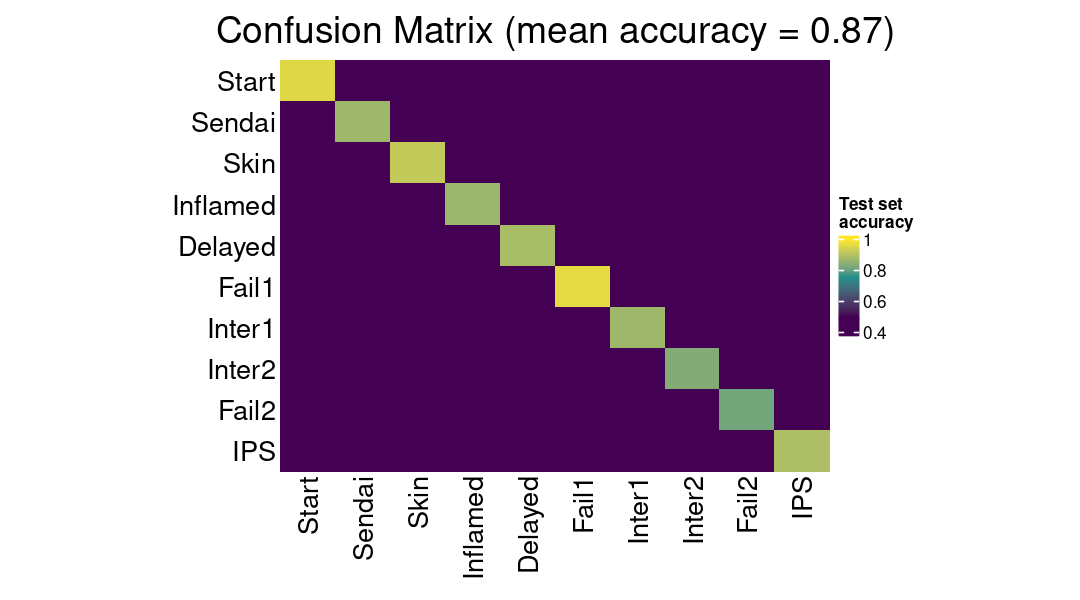

In [ ]:
multiome_conf_path = paste0(projdir, '/csv/figure1/snmct_rna_xgboost_conf_mtx.csv')
multiome_conf = as.data.frame(fread(multiome_conf_path, sep='\t'))
rownames(multiome_conf) <- multiome_conf[,1]
multiome_conf <- multiome_conf[ , -1]

    col_fun <- colorRamp2(c(0.5, 0.75, 1.0), viridis::viridis(3))

w = 9
h = 5
options(repr.plot.width=w, repr.plot.height=h)

igvf_heatmap <- Heatmap(multiome_conf,
                        name='Test set \naccuracy',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = 'Confusion Matrix (mean accuracy = 0.87)',
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_names_gp = gpar(fontsize=16),
                    column_names_gp = gpar(fontsize=16),
                    row_title_gp = gpar(fontsize = 22),
                    column_title_gp = gpar(fontsize = 22),
                    column_names_rot = 90,
                    heatmap_width = unit(14, "cm"),
                    heatmap_height = unit(12, "cm"),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)
igvf_heatmap

### B: 10x Multiome vs. snmCT-seq correlation

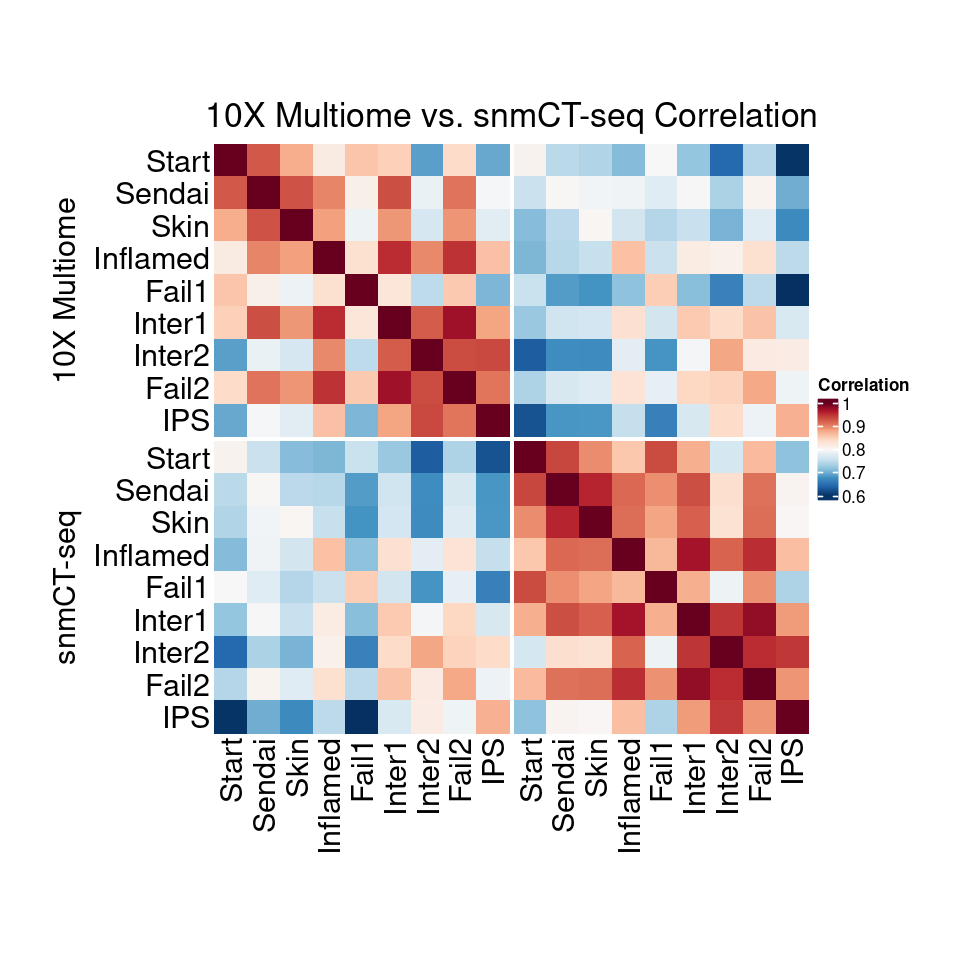

In [ ]:
corr_path = paste0(projdir, '/csv/figure1/multiome_snmct_pseudo_corr.csv')
corr = as.data.frame(fread(corr_path, sep='\t'))
k <- dim(corr)[2]
corr <- corr[,2:k]
rownames(corr) <- colnames(corr)

tmp_rows <- rownames(corr)
final_rows <- sub("\\.1$", "", tmp_rows)
rownames(corr) <- NULL
colnames(corr) <- NULL

col_fun <- colorRamp2(
  seq(min(corr), max(corr), length.out = 11),
  rev(brewer.pal(11, "RdBu"))
)

assay_split <- c(rep('10X Multiome', 9), rep('snmCT-seq', 9))

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=w)

corr_heatmap <- Heatmap(corr,
                        name='Correlation',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = '10X Multiome vs. snmCT-seq Correlation',
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_split=assay_split,
                    column_split=assay_split,
                    row_labels = final_rows,
                    column_labels = final_rows,
                    row_title_gp = gpar(fontsize = 18),
                    column_title_gp = gpar(fontsize = 20),
                    row_names_gp = gpar(fontsize = 18),
                    column_names_gp = gpar(fontsize = 18),
                    column_names_rot = 90,
                    heatmap_width = unit(16, "cm"),
                    heatmap_height = unit(16, "cm"),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)
corr_heatmap

### C: cell type distribution per day

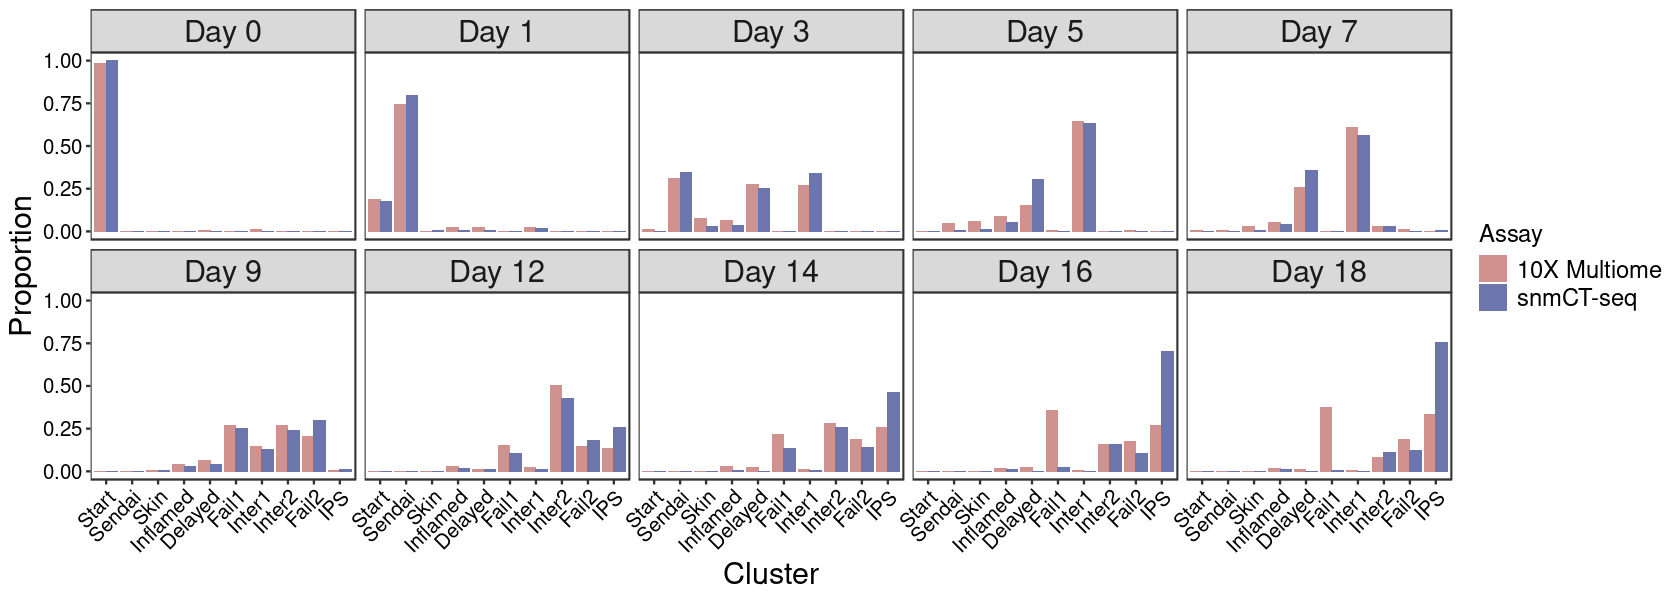

In [ ]:
merged_path = paste0(projdir, '/csv/figure1/xgboost_per_timepoint_clust_dist.csv')
merged = as.data.frame(fread(merged_path, sep='\t'))
merged$variable <- factor(merged$variable, levels=tmp_order)
merged[merged == "multiome"] <- "10X Multiome"
merged[merged == "snmct"] <- "snmCT-seq"

w = 14
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(merged, aes(x = variable, y = value, fill = assay)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~time_num, nrow = 2, ncol = 5,
             labeller = labeller(time_num = function(x) paste0("Day ", x))) +
  labs(x = "Cluster", y = "Proportion", fill = "Assay") +
  scale_y_continuous(limits = c(0, 1)) +
  scale_fill_manual(values=assay_hexes) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, color='black'),
    axis.text.y = element_text(size = 12, color='black'),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
    strip.text = element_text(size = 18),
    panel.grid = element_blank(),
    legend.text = element_text(size=14),
    legend.position = "right",
      legend.title = element_text(size=14)
  )

### D: cell type proportion per day, 10x RNA and snmCT RNA

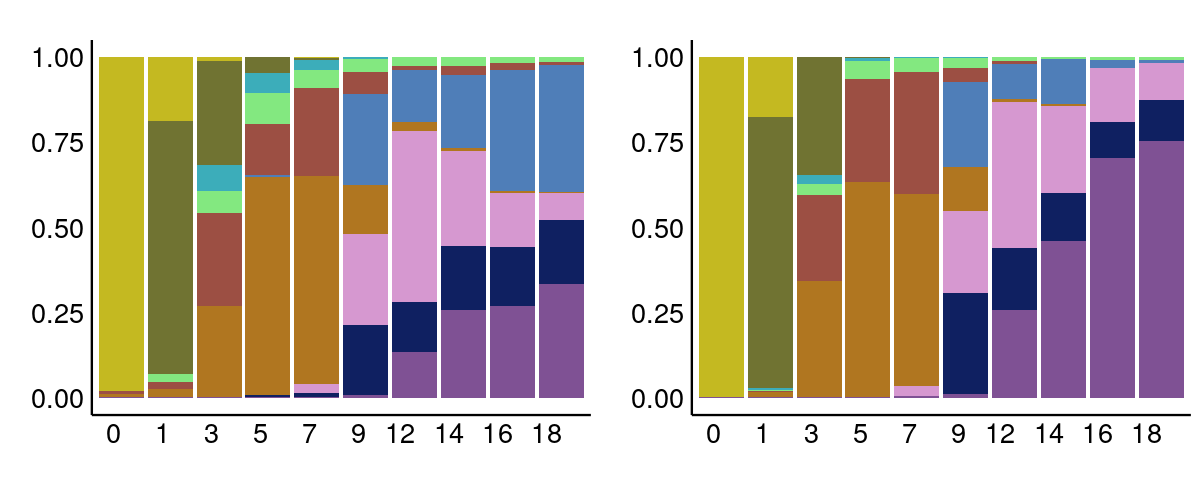

In [ ]:
merged_path = paste0(projdir, '/csv/figure1/multiome_snmct_clust_time_prop.csv')
merged = as.data.frame(fread(merged_path, sep='\t'))

mask <- merged$modality == '10X Multiome'
multiome_prop <- merged[mask,]
multiome_prop <- multiome_prop[,-ncol(multiome_prop)]

mask <- merged$modality == 'snmCT-seq'
snmct_prop <- merged[mask,]
snmct_prop <- snmct_prop[,-ncol(snmct_prop)]

multiome_prop_long <- multiome_prop %>%
  pivot_longer(
    cols = -V1,
    names_to = "state",
    values_to = "prop"
  )

snmct_prop_long <- snmct_prop %>%
  pivot_longer(
    cols = -V1,
    names_to = "state",
    values_to = "prop"
  )

multiome_prop_long$state <- factor(multiome_prop_long$state, levels=tmp_order)
snmct_prop_long$state <- factor(snmct_prop_long$state, levels=tmp_order)
multiome_prop_long$V1 <- factor(multiome_prop_long$V1)
snmct_prop_long$V1 <- factor(snmct_prop_long$V1)

w = 10
h = 4
options(repr.plot.width=w, repr.plot.height=h)

p1 <- ggplot(multiome_prop_long, aes(x = V1, y = prop, fill = state)) +
  geom_bar(stat = "identity") +
  labs(x = "",y = "",title = '') +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 16, angle = 0, hjust = 1, color='black'),
    axis.text.y = element_text(size = 16, color='black'),
    axis.line.x = element_line(color='black'),
    axis.line.y = element_line(color='black'),
    legend.position = "none"
  ) +
  scale_fill_manual(values=clust_hexes)

p2 <- ggplot(snmct_prop_long, aes(x = V1, y = prop, fill = state)) +
  geom_bar(stat = "identity") +
  labs(x = "",y = "",title = '') +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 16, angle = 0, hjust = 1, color='black'),
    axis.text.y = element_text(size = 16, color='black'),
    axis.line.x = element_line(color='black'),
    axis.line.y = element_line(color='black'),
    legend.position = "none"
  ) +
  scale_fill_manual(values=clust_hexes)

plot_grid(p1, p2)

### E: trajectory score per cluster

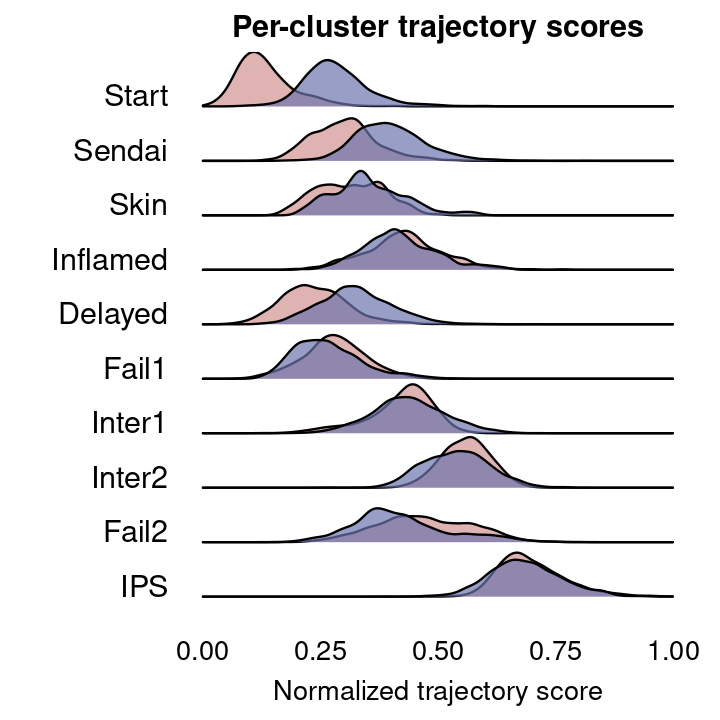

In [ ]:
assay_hexes <- c('#CF928F', '#6D75AD')
rev_order <- rev(tmp_order)

traj_path = paste0(projdir, '/csv/figure1/multiome_snmct_traj_score.csv')
traj_score = as.data.frame(fread(traj_path, sep='\t'))
traj_score$cluster <- factor(traj_score$cluster, levels=rev_order)

traj_score$norm_traj <- (traj_score$traj_score - min(traj_score$traj_score)) / (max(traj_score$traj_score) - min(traj_score$traj_score))

w = 6
h = 7
options(repr.plot.width=w, repr.plot.height=w)

ggplot(traj_score, aes(x = norm_traj, y = cluster, fill = assay)) +
  geom_density_ridges(scale = 1, alpha = 0.7, linewidth=0.1) +
  scale_x_continuous(limits = c(0, 1)) +
  labs(x = "Normalized trajectory score", y = "", title = 'Per-cluster trajectory scores') +
  theme_bw() +
  theme_ridges() +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5, size = 16, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title.x = element_text(size = 16, hjust=0.5),
    axis.title.y = element_text(size = 16),
    plot.title = element_text(size = 18, hjust=0.5),
    panel.grid = element_blank(),
    legend.text = element_text(size=10),
    legend.position = "none"
  ) +
  scale_fill_manual(values=assay_hexes)

### F: marker genes, 10x RNA and snmCT RNA

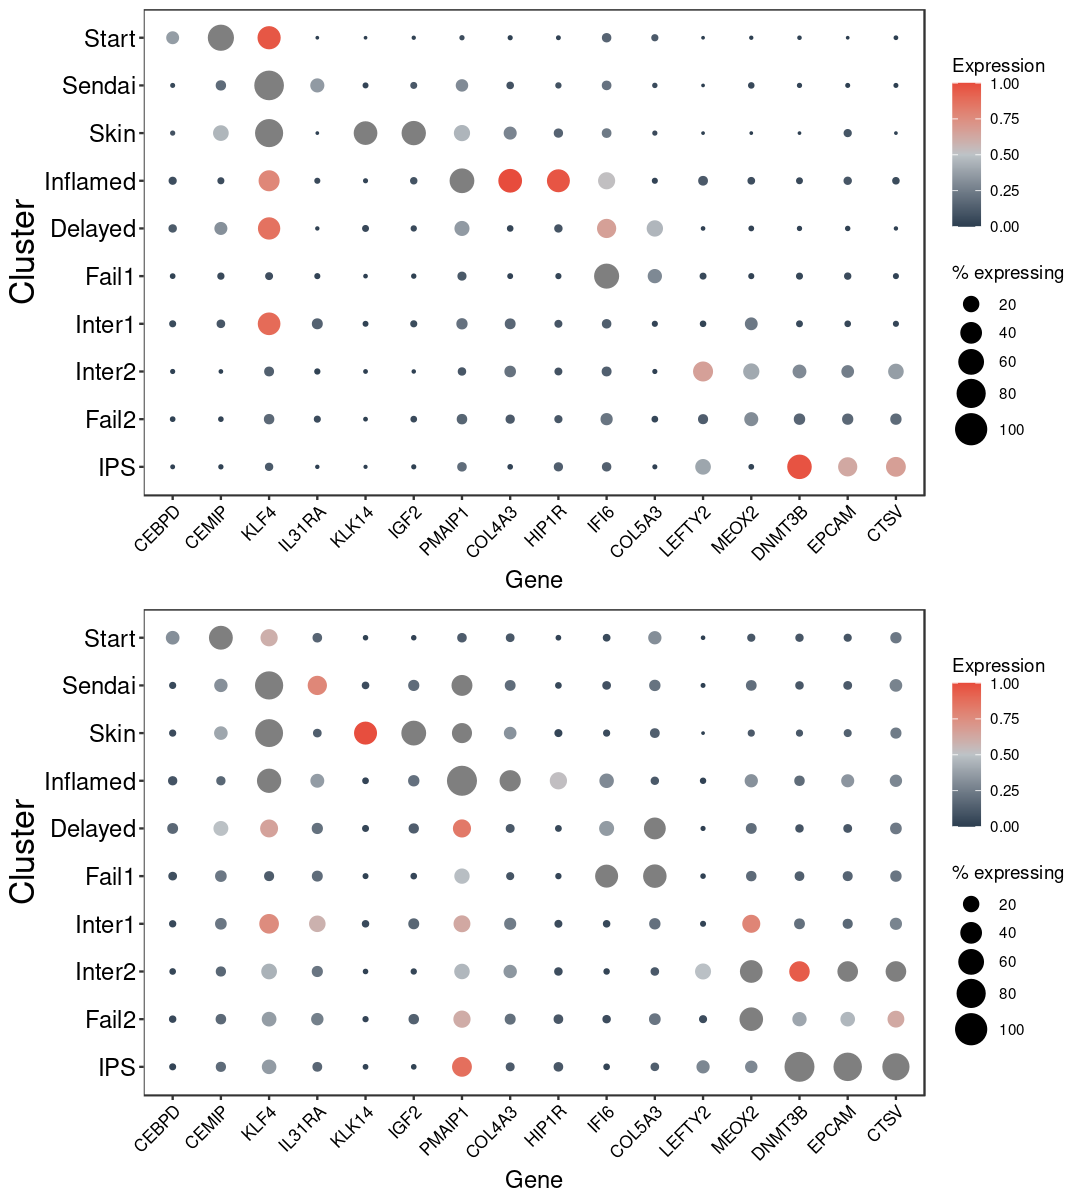

In [ ]:
multiome_path = paste0(projdir, '/csv/figure1/multiome_compare_dot_plot.csv')
multiome = as.data.frame(fread(multiome_path, sep='\t'))
rownames(multiome) <- multiome[,1]
multiome <- multiome[,-1]

multiome_meta_path = paste0(projdir, '/csv/figure1/multiome_compare_dot_plot_meta.csv')
multiome_meta = as.data.frame(fread(multiome_meta_path, sep='\t'))
colnames(multiome_meta) <- c('barcode', 'cluster')
multiome_meta <- multiome_meta[-1, ]
rownames(multiome_meta) <- multiome_meta$barcode

multiome_meta$cluster <- factor(multiome_meta$cluster, levels=tmp_order)

snmct_path = paste0(projdir, '/csv/figure1/snmct_compare_dot_plot.csv')
snmct = as.data.frame(fread(snmct_path, sep='\t'))
rownames(snmct) <- snmct[,1]
snmct <- snmct[,-1]

snmct_meta_path = paste0(projdir, '/csv/figure1/snmct_compare_dot_plot_meta.csv')
snmct_meta = as.data.frame(fread(snmct_meta_path, sep='\t'))
colnames(snmct_meta) <- c('barcode', 'cluster')
snmct_meta <- snmct_meta[-1, ]
rownames(snmct_meta) <- snmct_meta$barcode

snmct_meta$cluster <- factor(snmct_meta$cluster, levels=tmp_order)

tmp_genes <- colnames(multiome)
tmp_genes

cutoff <- 1

multiome$barcode <- rownames(multiome)
df <- multiome %>% inner_join(multiome_meta, by = "barcode")
df_long <- df %>% select(barcode, cluster, tmp_genes) %>% pivot_longer(cols = tmp_genes,
                                                                      names_to = "gene", values_to = "expr")
multiome_dot <- df_long %>%
  group_by(cluster, gene) %>% summarise(avg_expr = mean(expr), pct_expr = mean(expr > cutoff) * 100,.groups = "drop")
multiome_dot$gene <- factor(multiome_dot$gene, levels=tmp_genes)
multiome_dot$cluster <- factor(multiome_dot$cluster, levels=rev(tmp_order))

snmct$barcode <- rownames(snmct)
df <- snmct %>% inner_join(snmct_meta, by = "barcode")
df_long <- df %>% select(barcode, cluster, tmp_genes) %>% pivot_longer(cols = tmp_genes,
                                                                      names_to = "gene", values_to = "expr")
snmct_dot <- df_long %>%
  group_by(cluster, gene) %>% summarise(avg_expr = mean(expr), pct_expr = mean(expr > cutoff) * 100,.groups = "drop")
snmct_dot$gene <- factor(snmct_dot$gene, levels=tmp_genes)
snmct_dot$cluster <- factor(snmct_dot$cluster, levels=rev(tmp_order))

p1 <- ggplot(multiome_dot, aes(x = gene, y = cluster)) +
  geom_point(aes(size = pct_expr, color = avg_expr)) +

  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 1)) +
  scale_size_area(max_size = 8, breaks = c(20, 40, 60, 80, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=10, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=14, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=14, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

p2 <- ggplot(snmct_dot, aes(x = gene, y = cluster)) +
  geom_point(aes(size = pct_expr, color = avg_expr)) +

  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 1)) +
  scale_size_area(max_size = 8, breaks = c(20, 40, 60, 80, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=10, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=14, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=14, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

w = 9
h = 10
options(repr.plot.width=w, repr.plot.height=h)

final <- plot_grid(p1, p2, ncol = 1, align = "v")
final

### G: global mCG per day, snmCT/snm3C

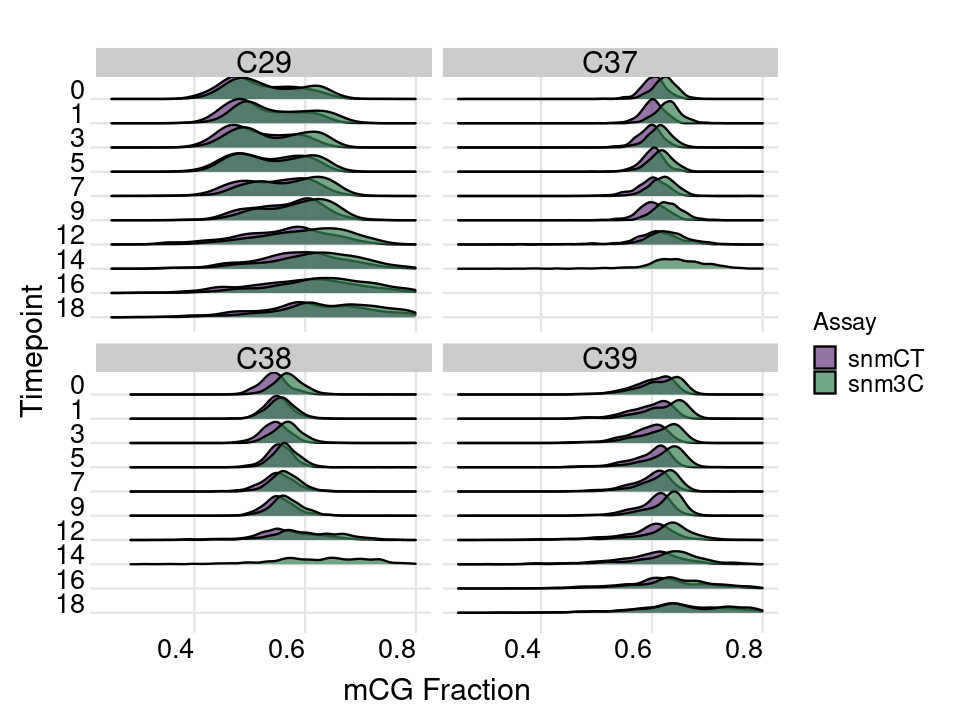

In [ ]:
times <- c('0','1','3','5','7','9','12','14','16','18')

mct_m3c_path <- '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/mc/csv/integrate_m3c/ridgeplot_mc.csv'
mct_m3c <- as.data.frame(fread(mct_m3c_path, sep='\t'))
mct_m3c$assay <- factor(mct_m3c$assay, levels=mcg_order)
mct_m3c$time <- factor(mct_m3c$time, levels=rev(times))

w = 8
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ggplot(mct_m3c, aes(x = value, y = time, fill=assay)) +
  geom_density_ridges(scale = 1, alpha = 0.7) +
  scale_x_continuous(limits = c(0.25, 0.8)) +
    scale_fill_manual(values=mcg_hexes) +
  labs(x = "mCG Fraction", y = "Timepoint", title = '', fill='Assay') +
  theme_minimal() +
  theme_ridges()  +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 1, size = 16, color='black'),
    axis.text.y = element_text(size = 16, color='black'),
    axis.title.x = element_text(size = 18, hjust=0.5),
    axis.title.y = element_text(size = 18, hjust=0.5),
    strip.text = element_text(size = 18),
    legend.text = element_text(size=14),
    legend.position = "right",
      legend.title = element_text(size=14)) +
    facet_wrap(~ donor)

### H: joint methylation UMAP by assay

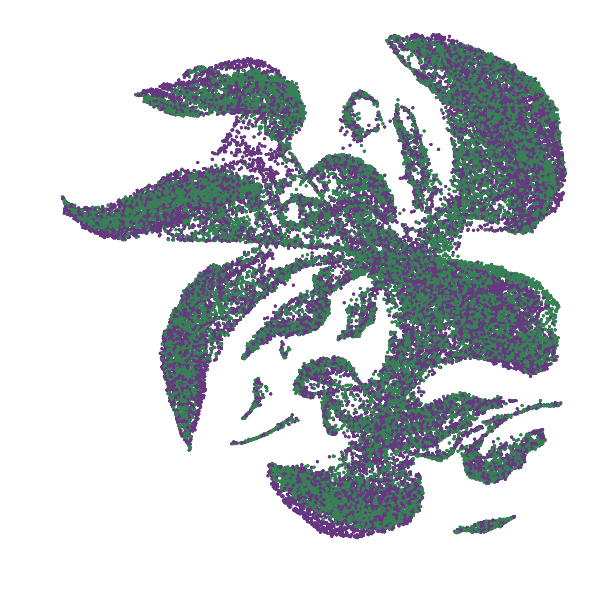

In [ ]:
mct_m3c_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure1/snmct_snm3c_mcg_umap.csv'
mct_m3c_umap <- as.data.frame(fread(mct_m3c_umap_path, sep='\t'))
mct_m3c_umap$assay <- factor(mct_m3c_umap$assay, levels=mcg_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_mct_m3c_umap <- mct_m3c_umap[sample(nrow(mct_m3c_umap)), ]

ggplot(shuffled_mct_m3c_umap, aes(x = umap0, y = umap1, color = assay)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", color = 'Assay') +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
        scale_color_manual(values = mcg_hexes)

### I: methylation cell type confusion matrix

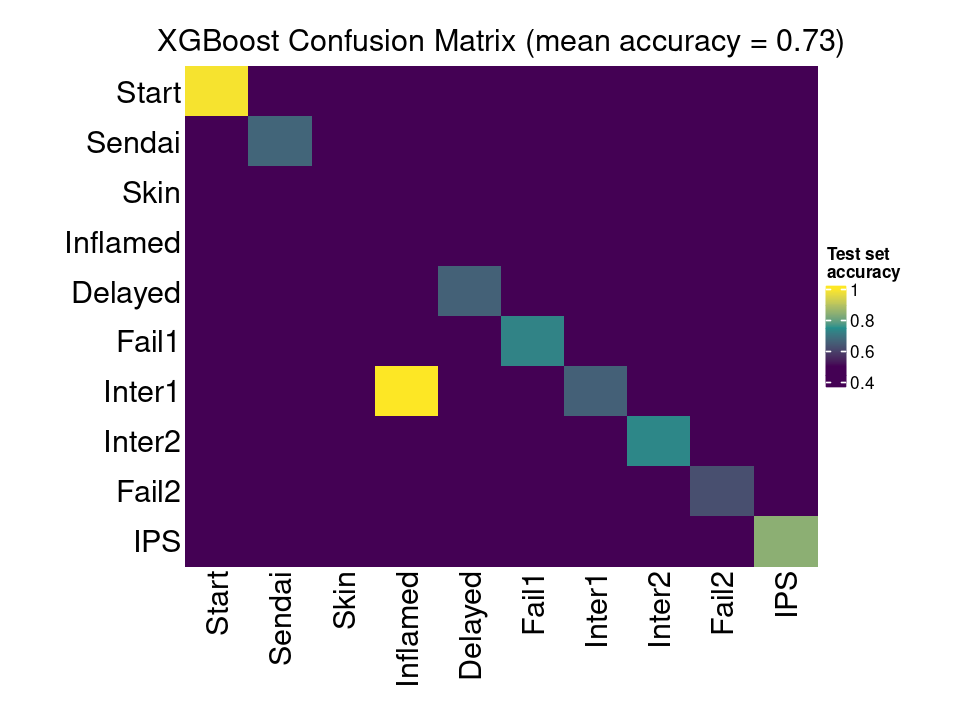

In [ ]:
conf_mtx_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure1/mct_xgboost_conf_mtx.csv'
conf_mtx <- as.data.frame(fread(conf_mtx_path, sep='\t'))
rownames(conf_mtx) <- conf_mtx$V1
conf_mtx <- conf_mtx[,-1]

col_fun <- colorRamp2(c(0.5, 0.75, 1.0), viridis::viridis(3))

w = 8
h = 6
options(repr.plot.width=w, repr.plot.height=h)
igvf_heatmap <- Heatmap(conf_mtx,
                        name='Test set \naccuracy',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = 'XGBoost Confusion Matrix (mean accuracy = 0.73)',
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_title_gp = gpar(fontsize = 18),
                    column_title_gp = gpar(fontsize = 18),
                   row_names_gp = gpar(fontsize = 18),
                    column_names_gp = gpar(fontsize = 18),
                    column_names_rot = 90,
                    heatmap_width = unit(16, "cm"),
                    heatmap_height = unit(14, "cm"),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)
igvf_heatmap

### J: classifier F1-score with upsampling

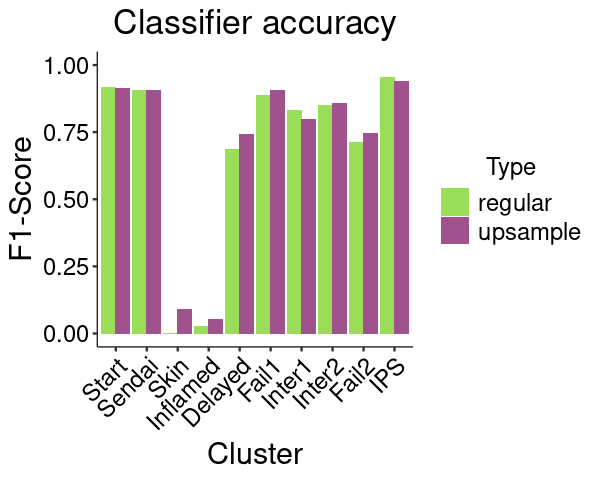

In [ ]:
upsample_order <- c('regular', 'upsample')
tmp_hexes <- c('#80B849', '#854476')
tmp_hexes <- adjustcolor(tmp_hexes, red.f = 1.2, green.f = 1.2, blue.f = 1.2)

upsample_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure1/compare_smote.csv'
upsample <- as.data.frame(fread(upsample_path, sep='\t'))
upsample$variable <- factor(upsample$variable, levels=upsample_order)
upsample$cluster <- factor(upsample$cluster, levels=tmp_order)

w = 5
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(upsample, aes(x = cluster, y = value, fill = variable)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(x = "Cluster", y = "F1-Score", title = 'Classifier accuracy', fill = "Type") +
  scale_y_continuous(limits = c(0, 1)) +
  scale_fill_manual(values=tmp_hexes) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14, color='black'),
    axis.text.y = element_text(size = 14, color='black'),
    plot.title = element_text(size = 20, hjust=0.5, color='black'),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
    axis.line = element_line(linewidth=0.25),
    axis.ticks.x = element_line(linewidth=0.5),
    axis.ticks.y = element_line(linewidth=0.5),
    legend.text = element_text(size=14),
      legend.title = element_text(size=14, hjust=0.5),
    legend.position = "right"
  ) +
          guides(color = guide_legend(override.aes = list(size = 4)),
            shape = guide_legend(title = 'Cluster'))

### K: classifier F1-score per feature set

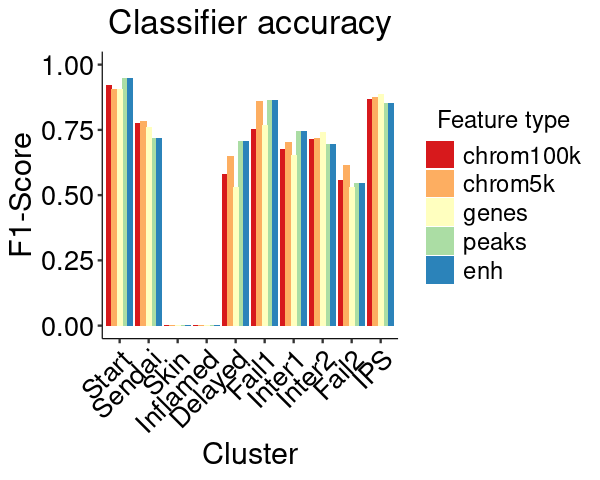

In [ ]:
features_order <- c('chrom100k', 'chrom5k', 'genes', 'peaks', 'enh')

features_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure1/mc_cluster_f1_scores_melt.csv'
features <- as.data.frame(fread(features_path, sep='\t'))
mask <- features$variable != 'dmrs'
features <- features[mask,]
features$variable <- factor(features$variable, levels=features_order)
features$cluster <- factor(features$cluster, levels=tmp_order)

w = 5
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(features, aes(x = cluster, y = value, fill = variable)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(x = "Cluster", y = "F1-Score",title = 'Classifier accuracy',fill = "Feature type") +
  scale_y_continuous(limits = c(0, 1)) +
  scale_fill_brewer(palette='Spectral') +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16, color='black'),
    axis.text.y = element_text(size = 16, color='black'),
    plot.title = element_text(size = 20, hjust = 0.5, color='black'),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
    axis.line = element_line(linewidth=0.25),
    axis.ticks.x = element_line(linewidth=0.5),
    axis.ticks.y = element_line(linewidth=0.5),
      legend.text = element_text(size=14),
      legend.title = element_text(size=14, hjust=0.5),
    legend.position = "right"
  )

### L: DMR methylation, snmCT/snm3C

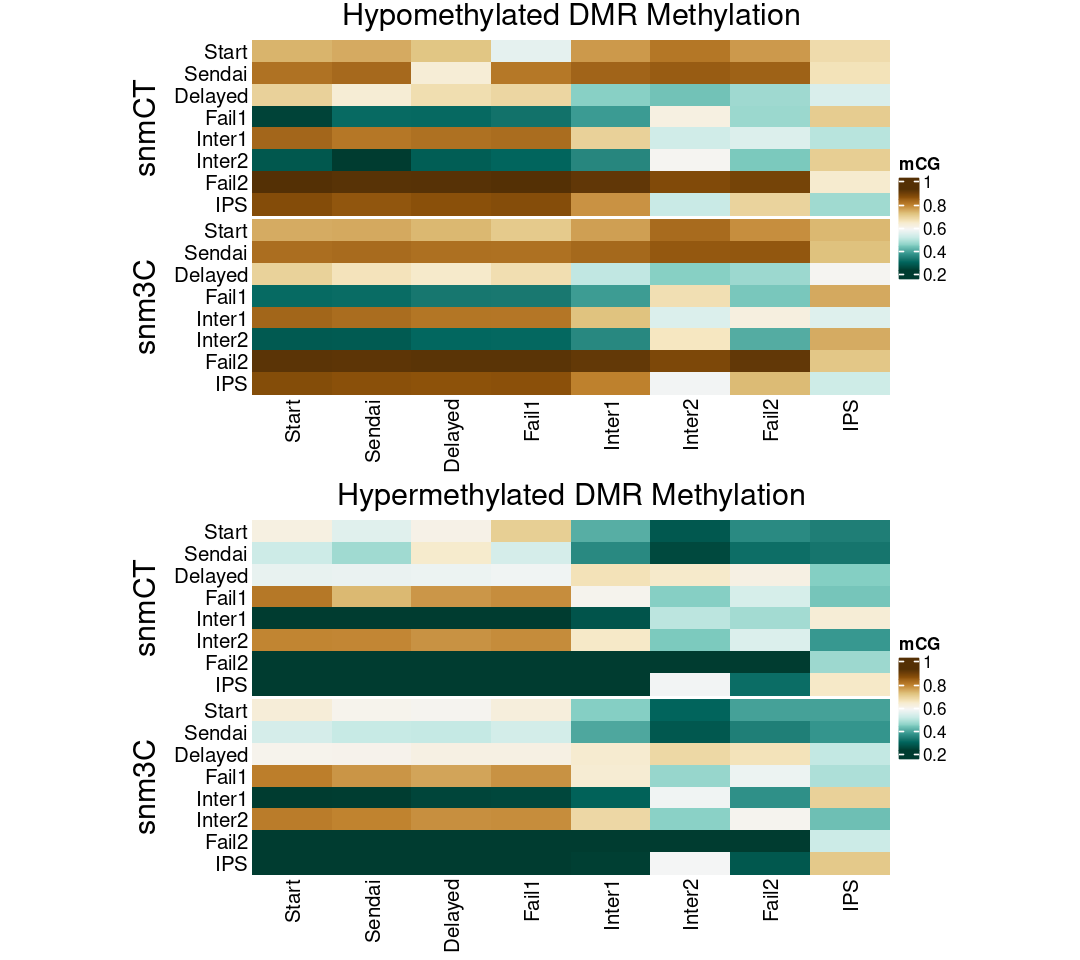

In [ ]:
final_order <- c('Start', 'Sendai', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')

indir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

snmct_hypo <- read.csv(paste0(indir, '/csv/figure1/snmct_hypo_dmrs.csv'), sep='\t', row.names=1)
snmct_hyper <- read.csv(paste0(indir, '/csv/figure1/snmct_hyper_dmrs.csv'), sep='\t', row.names=1)

snm3c_hypo <- read.csv(paste0(indir, '/csv/figure1/snm3c_hypo_dmrs.csv'), sep='\t', row.names=1)
snm3c_hyper <- read.csv(paste0(indir, '/csv/figure1/snm3c_hyper_dmrs.csv'), sep='\t', row.names=1)

merged_hypo <- rbind(snmct_hypo, snm3c_hypo)
hypo_rnames <- rep(final_order, 2)

merged_hyper <- rbind(snmct_hyper, snm3c_hyper)
hyper_rnames <- rep(final_order, 2)

assay_vec <- c(rep('snmCT', 8), rep('snm3C', 8))
assay_vec <- factor(assay_vec, levels = c('snmCT', 'snm3C'))
col_fun <- colorRamp2(
  seq(min(merged_hypo), max(merged_hypo), length.out = 11),
  rev(brewer.pal(11, "BrBG"))
)

options(repr.plot.width=8, repr.plot.height=4)
hypo_heatmap <- Heatmap(merged_hypo,
                        name='mCG',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = 'Hypomethylated DMR Methylation',
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_labels = hypo_rnames,
                    column_labels = final_order,
                    row_split = assay_vec,
                    row_title_gp = gpar(fontsize = 18),
                    column_title_gp = gpar(fontsize = 18),
                    column_names_rot = 90,
                    heatmap_width = unit(16, "cm"),
                    heatmap_height = unit(10, "cm"),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)

options(repr.plot.width=8, repr.plot.height=4)
hyper_heatmap <- Heatmap(merged_hyper,
                        name='mCG',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = 'Hypermethylated DMR Methylation',
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_labels = hyper_rnames,
                    column_labels = final_order,
                    row_split = assay_vec,
                    row_title_gp = gpar(fontsize = 18),
                    column_title_gp = gpar(fontsize = 18),
                    column_names_rot = 90,
                    heatmap_width = unit(16, "cm"),
                    heatmap_height = unit(10, "cm"),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)

w = 9
h = 8
options(repr.plot.width=w, repr.plot.height=h)

ht1_grob <- grid.grabExpr(draw(hypo_heatmap, heatmap_legend_side = "right"))
ht2_grob <- grid.grabExpr(draw(hyper_heatmap, heatmap_legend_side = "right"))
final <- plot_grid(ht1_grob, ht2_grob, ncol = 1, align = "v")

final

### M: methylation trajectory score

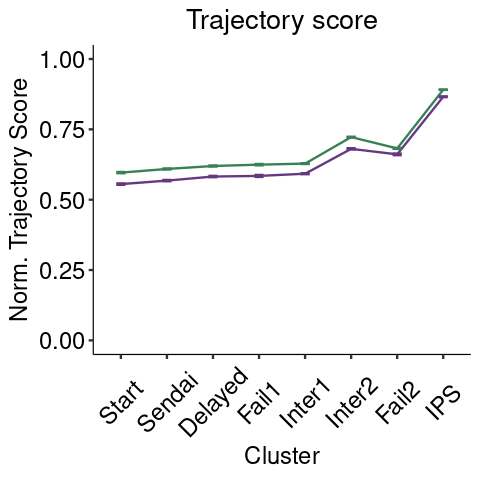

In [ ]:
traj_score_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure1/mct_m3c_traj_score.csv'
traj_score <- as.data.frame(fread(traj_score_path, sep='\t'))
traj_score$assay <- factor(traj_score$assay, levels=mcg_order)
traj_score$cluster <- factor(traj_score$cluster, levels=tmp_order)

mean_se_manual <- function(x) {
  data.frame(
    y    = mean(x, na.rm = TRUE),
    ymin = mean(x, na.rm = TRUE) - sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x))),
    ymax = mean(x, na.rm = TRUE) + sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x)))
  )
}

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(traj_score, aes(x = cluster, y = value, color = assay, group = assay)) +
  stat_summary(fun.data = mean_se_manual, geom = "line") +
  stat_summary(fun.data = mean_se_manual, geom = "errorbar", width = 0.2) +
  labs(x = "Cluster", y = "Norm. Trajectory Score",
       title = "Trajectory score", color='Assay') +
  scale_y_continuous(limits = c(0, 1)) +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_text(size=14,angle=45, color='black', vjust=0.5),
        axis.text.y = element_text(size=14,angle=0, color='black'),
        axis.title.x = element_text(size=14),
        axis.title.y = element_text(size=14),
         axis.line.x = element_line(linewidth=0.25),
         axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
        plot.title = element_text(size = 16, hjust = 0.5)) +
        scale_color_manual(values = mcg_hexes) +
          guides(color = guide_legend(override.aes = list(linewidth = 2)),
            shape = guide_legend(title = ''))

In [ ]:
sessionInfo()

In [ ]:
Sys.time()